#### Stats post-processing

This notebook performs the post-processing of the statistical data. More specifically, it goes through the following steps:
1. reads the `stats1` and `stats2` files of each block and plots any variable
2. computes the total pressure field across the domain, the measurement planes and the mixed out loss
3. plots the isentropic Mach and loss coefficient distributions
4. computes the inlet/outlet angles of the flow.

**Notes**: the notebook relies on adjustments of functions and processing methods written by J. Liu, C. Matar, and L. Zemmour. 

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from musicaa_utils import get_block_info, line_interp, mixed_out, plot_grid, read_grid, read_info, read_stats

def read_case(input_dir, dict_input, plot_mesh=False):

    pitch      = dict_input['pitch']
    cax        = dict_input['cax']
    x1         = dict_input['x1']
    x2         = dict_input['x2']
    in_blocks  = dict_input['in_blocks']
    out_blocks = dict_input['out_blocks']

    dict_info = read_info(input_dir)
    block_info = get_block_info(input_dir)
    data = {}
    ngh = int(dict_info["ngh"])
    n_block = dict_info["nbloc"]
    Re_in  = dict_info['Reref']
    u_in   = dict_info['Uref']
    p_in   = dict_info['Pref']
    rho_in = dict_info['Roref']
    mu_in  = dict_info['Muref']
    c_in   = dict_info['cref']
    nz     = dict_info['nz_bl1']

    for bl in range(1, n_block + 1):
        data[bl] = {}
        # read grid
        bl_file = os.path.join(input_dir, f'grid_bl{bl}_ngh{ngh}.bin')
        nx, ny, nz, x, y, z = read_grid(input_dir, bl_file)
        # scale grid
        data[bl]["x"], data[bl]["y"], data[bl]["z"] = x, y, z

    # Plot mesh
    if plot_mesh is True:

        plot_grid(input_dir, True, n_bl=n_block, every=5, figsize=(5.2, 3.64))

    # The sensors coordinates are also extracted for each block

    sensor = {}
    for bl in range(1, n_block + 1):
        sensor[bl] = []
        nb_pt = block_info[f"block_{bl}"]["nb_points"]
        nb_li = block_info[f"block_{bl}"]["nb_lines"]
        if nb_pt > 0:
            for pt in range(1, nb_pt + 1):
                xs = block_info[f"block_{bl}"][f"point_{pt}"]["nx1"]
                ys = block_info[f"block_{bl}"][f"point_{pt}"]["ny1"]
                sensor[bl].append([xs, ys])
                print(f"point in block {bl} at indexes {xs, ys}")
        if nb_li > 0:
            for li in range(1, nb_li + 1):
                xs = block_info[f"block_{bl}"][f"line_{li}"]["nx1"]
                ys = block_info[f"block_{bl}"][f"line_{li}"]["ny1"]
                sensor[bl].append([xs, ys])
                print(f"line in block {bl} at indexes {xs, ys}")

    # Statistics dictionary are created and filled with each block's data

    stats1 = {}
    stats2 = {}
    for bl in range(1, n_block + 1):
        nx, ny = block_info[f"block_{bl}"]["nx"], block_info[f"block_{bl}"]["ny"]
        stats1[bl] = read_stats(os.path.join(input_dir, f"stats1_bl{bl}.bin"), nx, ny)
        stats2[bl] = read_stats(os.path.join(input_dir, f"stats2_bl{bl}.bin"), nx, ny)

    # union of data
    in_data = {}
    for bl in in_blocks:
        in_data[bl] = data[bl] | stats1[bl] | stats2[bl]

    out_data = {}
    for bl in out_blocks:
        out_data[bl] = data[bl] | stats1[bl] | stats2[bl]

    # The limits along the y axis of both measurement planes are computed 

    # find y corresponding to x1
    x0 = in_data[in_blocks[0]]["x"]
    closest_index = np.argmin(abs(x0[:, 0] - x1))
    y1 = in_data[in_blocks[0]]["y"][closest_index, :].min()
    y2 = y1 + pitch
    # compute interpolation axis
    y_in = np.linspace(y1, y2, 1000)
    # build inlet_lims
    inlet_lims = [x1, y1, x1, y2]
    print(f"inlet_lims: {inlet_lims}")

    # find y corresponding to x1
    x0 = out_data[out_blocks[0]]["x"]
    closest_index = np.argmin(abs(x0[:, 0] - x2))
    y1 = out_data[out_blocks[0]]["y"][closest_index, :].min()
    y2 = y1 + pitch
    # compute interpolation axis
    y_out = np.linspace(y1, y2, 1000)
    outlet_lims = [x2, y1, x2, y2]
    print(f"outlet_lims: {outlet_lims}")


    data_inlet = {}
    data_outlet = {}
    for var in ["uu", "vv", "ww", "rhou", "rhov", "rho*uu", "rho*uv", "rho*uw", "p", "T", "M", "cp", "cv"]:
        data_inlet[f"{var}_interp"] = line_interp(in_data, var, inlet_lims, in_blocks)
        data_outlet[f"{var}_interp"] = line_interp(out_data, var, outlet_lims, out_blocks)

    results = {'data_inlet': data_inlet,
               'data_outlet': data_outlet,
               'stats1': stats1,
               'stats2': stats2,
               'data': data,
               'inlet_lims': inlet_lims,
               'outlet_lims': outlet_lims,
               'y_out': y_out,
               'n_block': n_block,
               'sensor': sensor}

    return results

def compute_total_pressure(data, stats1, stats2, inlet_lims, outlet_lims, n_block, dict_input):

    # The total Pressure field is first computed

    pres_tot = {bl:[] for bl in range(1, n_block + 1)}

    for bl in range(1, n_block + 1):
        cp = stats2[bl]['cp']
        cv = stats2[bl]['cv']
        gamma = cp / cv
        Mach = stats2[bl]['M']
        pres = stats1[bl]['p']
        pres_tot[bl] = pres * (1 + (gamma - 1) / 2 * Mach**2)**(gamma / (gamma - 1))

    in_data = {}
    for bl in dict_input["in_blocks"]:
        in_data[bl] = data[bl] | stats1[bl] | stats2[bl]

    out_data = {}
    for bl in dict_input["out_blocks"]:
        out_data[bl] = data[bl] | stats1[bl] | stats2[bl]

    # The data is interpolated along the measurement planes

    data_inlet = {}
    data_outlet = {}
    for var in ["uu", "vv", "ww", "rhou", "rhov", "rho*uu", "rho*uv", "rho*uw", "p", "T", "M", "cp", "cv"]:
        data_inlet[f"{var}_interp"] = line_interp(in_data, var, inlet_lims, dict_input["in_blocks"])
        data_outlet[f"{var}_interp"] = line_interp(out_data, var, outlet_lims, dict_input["out_blocks"])

    # The mixed out loss coefficient is computed

    # add gam and R entries as required by mixed_out
    data_inlet["gam"] = np.nanmean(data_inlet["cp_interp"] / data_inlet["cv_interp"])
    data_inlet["R"] = np.nanmean(data_inlet["cp_interp"] - data_inlet["cv_interp"])
    data_outlet["gam"] = data_inlet["gam"]
    data_outlet["R"] = data_inlet["R"]
    # compute inlet/outlet mixed out states
    inlet_mixed_out_state = mixed_out(data_inlet)
    outlet_mixed_out_state = mixed_out(data_outlet)
    # compute mixed out loss
    mo_loss = (inlet_mixed_out_state["p0_bar"] - outlet_mixed_out_state["p0_bar"]) / (inlet_mixed_out_state["p0_bar"] - inlet_mixed_out_state["p_bar"])
    print(f"Mixed out loss: {mo_loss}")

    # =============================================================================
    # 3. Loss coefficient and isentropic Mach distributions
    # =============================================================================
    # The additional input variables are:
    # * `path_to_loss` the path to the loss measurements
    # * `path_to_mis` the path to the isentropic Mach measurements
    # * `wall_blocks` the list of blocks encompassing the geometry walls.

    in_idx =  np.argwhere(~np.isnan(data_inlet["rhou_interp"]))
    q1 = np.sum(data_inlet["rhou_interp"][in_idx])
    P1 = np.sum(data_inlet["rhou_interp"][in_idx] * data_inlet["p_interp"][in_idx]) / q1
    gamma = np.mean(data_inlet["cp_interp"][in_idx] / data_inlet["cv_interp"][in_idx])
    P01 = np.sum(data_inlet["p_interp"][in_idx] * (1 + (gamma - 1 ) / 2 * data_inlet["M_interp"][in_idx]**2)**(gamma / (gamma - 1)) * data_inlet["rhou_interp"][in_idx]) / q1

    out_idx =  np.argwhere(~np.isnan(data_outlet["rhou_interp"]))
    q2 = np.sum(data_outlet["rhou_interp"][out_idx])
    P2 = np.sum(data_outlet["rhou_interp"][out_idx] * data_outlet["p_interp"][out_idx]) / q2
    gamma = np.mean(data_outlet["cp_interp"][out_idx] / data_outlet["cv_interp"][out_idx])
    print(f"gamma: {gamma}")
    P02 = np.sum(data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1)) * data_outlet["rhou_interp"][out_idx]) / q2

    print(f"Loss coefficient w: {(P01 - P02) / (P01 - P1)}")

    loss = (P01 - data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1))) / (P01 - P1)
    delta= 0.0225

    return out_idx, loss, P01, gamma

In [3]:
# plot params
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = "Times"
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
figsize = (5.2, 3.64)

path_to_mis = "cascade_mis.dat"

dict_input_case = {'pitch': 40.39, 'cax': 0.067, 'x1': -20.108296, 'x2': 87.25188, 'in_blocks': [1, 2], 'out_blocks': [8, 9], 'wall_blocks': [3, 4, 7, 6]}

bestLES = [6, 0, 3]

input_dir_ADP_1 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[0]}/high_infill_{bestLES[0]}/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_1 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[0]}/high_infill_{bestLES[0]}/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
input_dir_OP2_1 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[0]}/high_infill_{bestLES[0]}/MUSICAA/musicaa_g0_c0/OP2" # "OP2"

input_dir_ADP_2 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[1]}/high_infill_{bestLES[1]}/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_2 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[1]}/high_infill_{bestLES[1]}/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
input_dir_OP2_2 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[1]}/high_infill_{bestLES[1]}/MUSICAA/musicaa_g0_c0/OP2" # "OP2"

input_dir_ADP_3 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[2]}/high_infill_{bestLES[2]}/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_3 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[2]}/high_infill_{bestLES[2]}/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
input_dir_OP2_3 = f"/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_{bestLES[2]}/high_infill_{bestLES[2]}/MUSICAA/musicaa_g0_c0/OP2" # "OP2"

input_dir_ADP_b = "/home/mciarlatani/Hilbert/aero-optim/examples/LRN-CASCADE/cascade_musicaa_base/output_baseline/MUSICAA/musicaa_g0_c0/ADP" # "ADP"
input_dir_OP1_b = "/home/mciarlatani/Hilbert/aero-optim/examples/LRN-CASCADE/cascade_musicaa_base/output_baseline/MUSICAA/musicaa_g0_c0/OP1" # "OP1"
input_dir_OP2_b = "/home/mciarlatani/Hilbert/aero-optim/examples/LRN-CASCADE/cascade_musicaa_base/output_baseline/MUSICAA/musicaa_g0_c0/OP2" # "OP2"

ADP_1 = read_case(input_dir_ADP_1, dict_input_case)
OP1_1 = read_case(input_dir_OP1_1, dict_input_case)
OP2_1 = read_case(input_dir_OP2_1, dict_input_case)

ADP_2 = read_case(input_dir_ADP_2, dict_input_case)
OP1_2 = read_case(input_dir_OP1_2, dict_input_case)
OP2_2 = read_case(input_dir_OP2_2, dict_input_case)

ADP_3 = read_case(input_dir_ADP_3, dict_input_case)
OP1_3 = read_case(input_dir_OP1_3, dict_input_case)
OP2_3 = read_case(input_dir_OP2_3, dict_input_case)

ADP_b = read_case(input_dir_ADP_b, dict_input_case)
OP1_b = read_case(input_dir_OP1_b, dict_input_case)
OP2_b = read_case(input_dir_OP2_b, dict_input_case)

Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
line in block 1 at indexes (30, 1)
line in block 1 at indexes (1, 1)
line in block 7 at indexes (20, 30)
line in block 8 at indexes (1, 1)
line in block 8 at indexes (30, 1)
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
inlet_lims: [-20.108296, -1.48688895001071, -20.108296, 38.90311104998929]
outlet_lims: [87.25188, 10.4273182046719, 87.25188, 50.8173182046719]
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
line in block 1 at indexes (30, 1)
line in block 1 at indexes (1, 1)
line in block 7 at

In [8]:
out_idx_ADP_1, loss_ADP_1, P01_ADP_1, gamma_ADP_1 = compute_total_pressure(ADP_1['data'], ADP_1['stats1'], ADP_1['stats2'], ADP_1['inlet_lims'], ADP_1['outlet_lims'], ADP_1['n_block'], dict_input_case)
out_idx_OP1_1, loss_OP1_1, P01_OP1_1, gamma_OP1_1 = compute_total_pressure(OP1_1['data'], OP1_1['stats1'], OP1_1['stats2'], OP1_1['inlet_lims'], OP1_1['outlet_lims'], OP1_1['n_block'], dict_input_case)
out_idx_OP2_1, loss_OP2_1, P01_OP2_1, gamma_OP2_1 = compute_total_pressure(OP2_1['data'], OP2_1['stats1'], OP2_1['stats2'], OP2_1['inlet_lims'], OP2_1['outlet_lims'], OP2_1['n_block'], dict_input_case)

out_idx_ADP_2, loss_ADP_2, P01_ADP_2, gamma_ADP_2 = compute_total_pressure(ADP_2['data'], ADP_2['stats1'], ADP_2['stats2'], ADP_2['inlet_lims'], ADP_2['outlet_lims'], ADP_2['n_block'], dict_input_case)
out_idx_OP1_2, loss_OP1_2, P01_OP1_2, gamma_OP1_2 = compute_total_pressure(OP1_2['data'], OP1_2['stats1'], OP1_2['stats2'], OP1_2['inlet_lims'], OP1_2['outlet_lims'], OP1_2['n_block'], dict_input_case)
out_idx_OP2_2, loss_OP2_2, P01_OP2_2, gamma_OP2_2 = compute_total_pressure(OP2_2['data'], OP2_2['stats1'], OP2_2['stats2'], OP2_2['inlet_lims'], OP2_2['outlet_lims'], OP2_2['n_block'], dict_input_case)

out_idx_ADP_3, loss_ADP_3, P01_ADP_3, gamma_ADP_3 = compute_total_pressure(ADP_3['data'], ADP_3['stats1'], ADP_3['stats2'], ADP_3['inlet_lims'], ADP_3['outlet_lims'], ADP_3['n_block'], dict_input_case)
out_idx_OP1_3, loss_OP1_3, P01_OP1_3, gamma_OP1_3 = compute_total_pressure(OP1_3['data'], OP1_3['stats1'], OP1_3['stats2'], OP1_3['inlet_lims'], OP1_3['outlet_lims'], OP1_3['n_block'], dict_input_case)
out_idx_OP2_3, loss_OP2_3, P01_OP2_3, gamma_OP2_3 = compute_total_pressure(OP2_3['data'], OP2_3['stats1'], OP2_3['stats2'], OP2_3['inlet_lims'], OP2_3['outlet_lims'], OP2_3['n_block'], dict_input_case)

out_idx_ADP_b, loss_ADP_b, P01_ADP_b, gamma_ADP_b = compute_total_pressure(ADP_b['data'], ADP_b['stats1'], ADP_b['stats2'], ADP_b['inlet_lims'], ADP_b['outlet_lims'], ADP_b['n_block'], dict_input_case)
out_idx_OP1_b, loss_OP1_b, P01_OP1_b, gamma_OP1_b = compute_total_pressure(OP1_b['data'], OP1_b['stats1'], OP1_b['stats2'], OP1_b['inlet_lims'], OP1_b['outlet_lims'], OP1_b['n_block'], dict_input_case)
out_idx_OP2_b, loss_OP2_b, P01_OP2_b, gamma_OP2_b = compute_total_pressure(OP2_b['data'], OP2_b['stats1'], OP2_b['stats2'], OP2_b['inlet_lims'], OP2_b['outlet_lims'], OP2_b['n_block'], dict_input_case)

Mixed out loss: 0.028159647772603043
gamma: 1.4000000000000414
Loss coefficient w: 0.024993848121581588
Mixed out loss: 0.07038787386509904
gamma: 1.4000000000003552
Loss coefficient w: 0.05439866520246228
Mixed out loss: 0.03434785304871279
gamma: 1.3999999999999029
Loss coefficient w: 0.031079968704298334
Mixed out loss: 0.031050196987993092
gamma: 1.4000000000002333
Loss coefficient w: 0.027805231699927872
Mixed out loss: 0.05621457353117522
gamma: 1.4000000000004398
Loss coefficient w: 0.04836078422639288
Mixed out loss: 0.038170854660073215
gamma: 1.4000000000000428
Loss coefficient w: 0.03447600428365649
Mixed out loss: 0.033312208524645774
gamma: 1.400000000000187
Loss coefficient w: 0.02983655456353532
Mixed out loss: 0.049873312873075316
gamma: 1.4000000000000814
Loss coefficient w: 0.040011762279707576
Mixed out loss: 0.03863799709775757
gamma: 1.4000000000000268
Loss coefficient w: 0.034881004746814596
Mixed out loss: 0.03487412184979889
gamma: 1.399999999999995
Loss coeffic

In [9]:
loss_to_plot = [[ADP_1['y_out'], out_idx_ADP_1, loss_ADP_1],[OP1_1['y_out'], out_idx_OP1_1, loss_OP1_1],[OP2_1['y_out'], out_idx_OP2_1, loss_OP2_1], 
                [ADP_2['y_out'], out_idx_ADP_2, loss_ADP_2],[OP1_2['y_out'], out_idx_OP1_2, loss_OP1_2],[OP2_2['y_out'], out_idx_OP2_2, loss_OP2_2],
                [ADP_3['y_out'], out_idx_ADP_3, loss_ADP_3],[OP1_3['y_out'], out_idx_OP1_3, loss_OP1_3],[OP2_3['y_out'], out_idx_OP2_3, loss_OP2_3],
                [ADP_b['y_out'], out_idx_ADP_b, loss_ADP_b],[OP1_b['y_out'], out_idx_OP1_b, loss_OP1_b],[OP2_b['y_out'], out_idx_OP2_b, loss_OP2_b]]

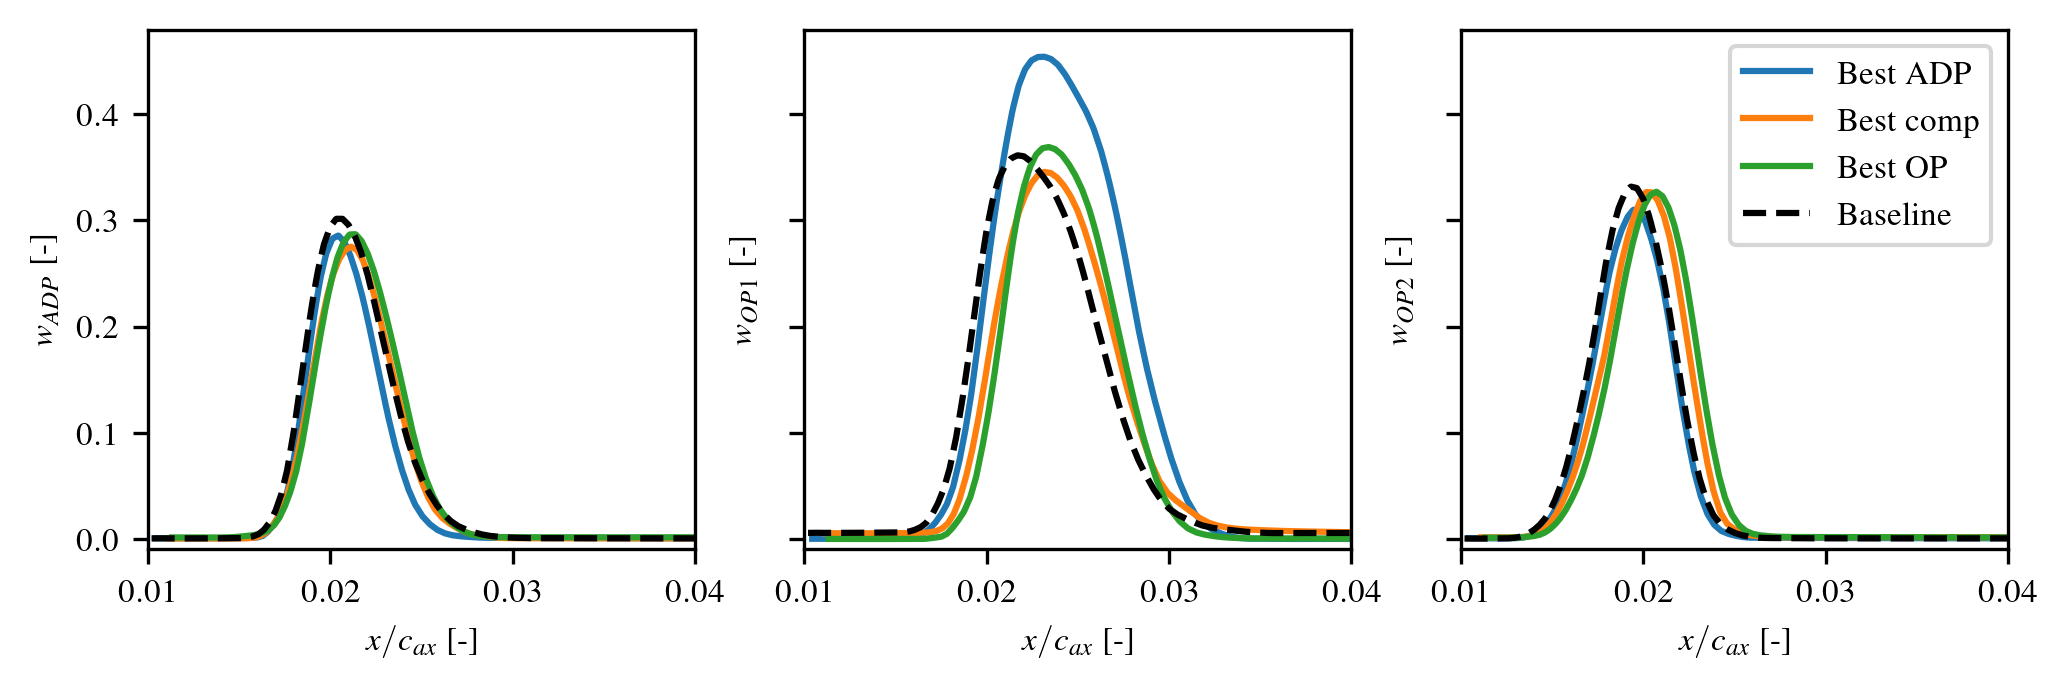

In [10]:
fig = plt.figure(figsize=(8,2.25))
for i in range(len(loss_to_plot)):
    y_out, out_idx, loss = loss_to_plot[i]
    idx = i%3+1
    ax = plt.subplot(1, 3, idx)

    if i//3==0:
        color, line, lab = ['tab:blue', '-', 'Best ADP']
    if i//3==1:
        color, line, lab = ['tab:orange', '-', 'Best comp']
    if i//3==2:
        color, line, lab = ['tab:green', '-', 'Best OP']
    if i//3==3:
        color, line, lab = ['black', '--', 'Baseline']
    ax.plot(y_out[out_idx] / 1000, loss, label=lab, color=color, linestyle=line)

    if idx == 1:
        ax.set_ylabel(r'$w_{ADP}$ [-]')
    if idx == 2:
        ax.set_ylabel(r'$w_{OP1}$ [-]')
        ax.set_yticklabels([])
    if idx == 3:
        ax.set_ylabel(r'$w_{OP2}$ [-]')
        ax.set_yticklabels([])
        ax.legend()
    
    ax.set_xlabel('$x/c_{ax}$ [-]')
    ax.set_xlim([0.01,0.04])
    ax.set_ylim([-0.01,0.48])

plt.legend()
plt.show()

In [11]:
Mis_to_plot = [[ADP_1, P01_ADP_1, gamma_ADP_1],[OP1_1, P01_OP1_1, gamma_OP1_1],[OP2_1, P01_OP2_1, gamma_OP2_1], 
               [ADP_2, P01_ADP_2, gamma_ADP_2],[OP1_2, P01_OP1_2, gamma_OP1_2],[OP2_2, P01_OP2_2, gamma_OP2_2],
               [ADP_3, P01_ADP_3, gamma_ADP_3],[OP1_3, P01_OP1_3, gamma_OP1_3],[OP2_3, P01_OP2_3, gamma_OP2_3],
               [ADP_b, P01_ADP_b, gamma_ADP_b],[OP1_b, P01_OP1_b, gamma_OP1_b],[OP2_b, P01_OP2_b, gamma_OP2_b]]

/tmp/ipykernel_212149/979087484.py:39: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)
/tmp/ipykernel_212149/979087484.py:39: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)
/tmp/ipykernel_212149/979087484.py:39: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)
/tmp/ipykernel_212149/979087484.py:39: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)
/tmp/ipykernel_212149/979087484.py:39: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)
/tmp/ipykernel_212149/979087484.py:39: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)


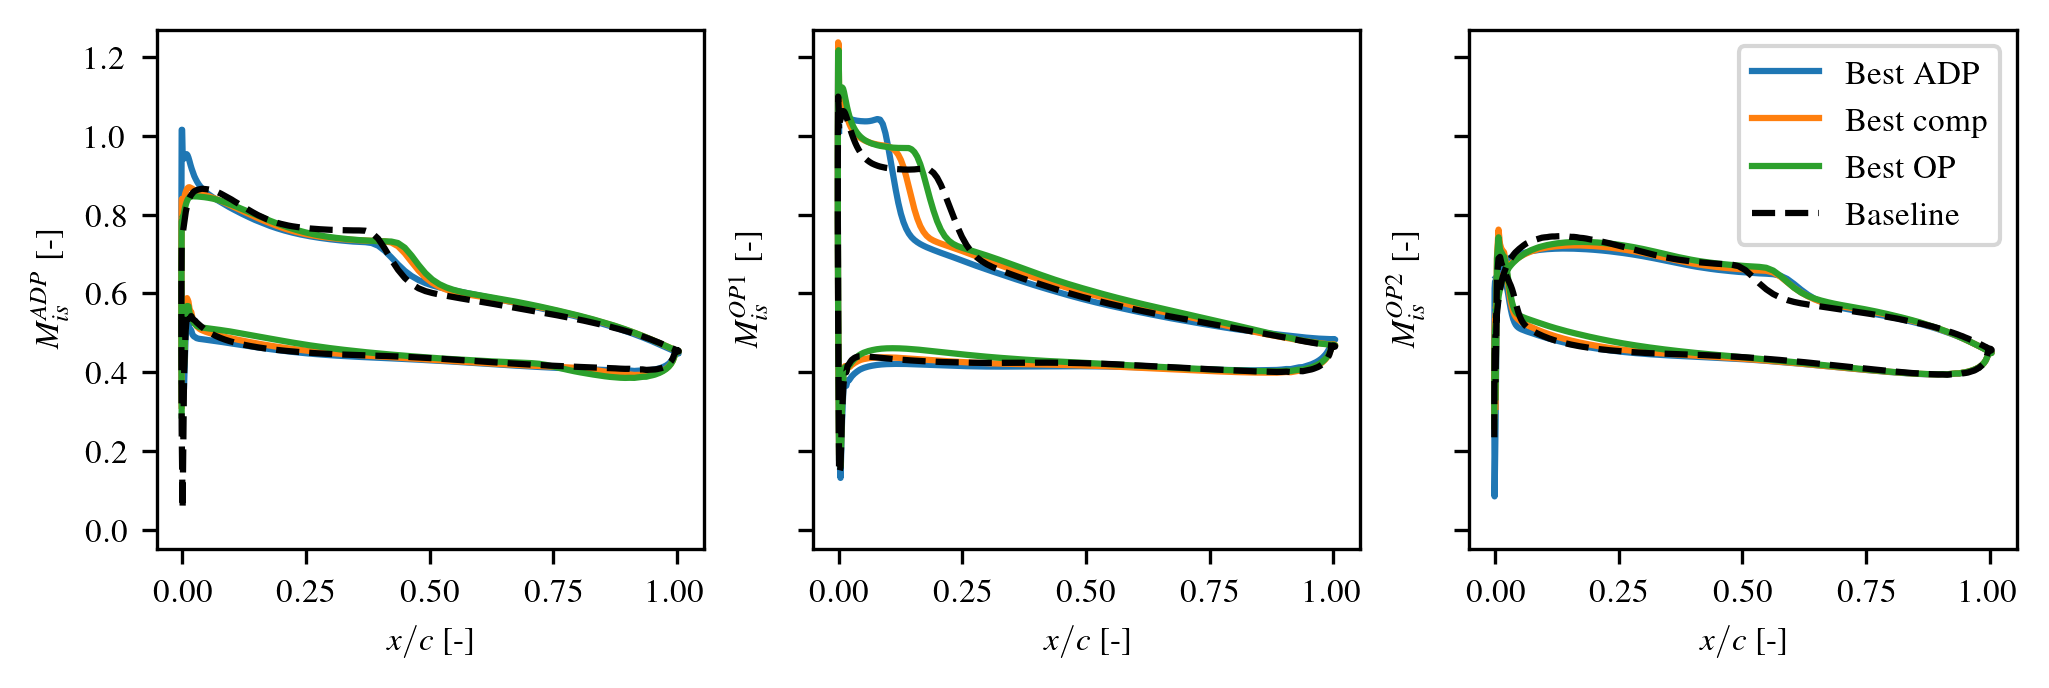

In [13]:
fig = plt.figure(figsize=(8,2.25))

for i in range(len(loss_to_plot)):
    case, P01, gamma = elem = Mis_to_plot[i]
    idx = i%3+1
    ax = plt.subplot(1, 3, idx)

    if i//3==0:
        color, line, lab = ['tab:blue', '-', 'Best ADP']
    if i//3==1:
        color, line, lab = ['tab:orange', '-', 'Best comp']
    if i//3==2:
        color, line, lab = ['tab:green', '-', 'Best OP']
    if i//3==3:
        color, line, lab = ['black', '--', 'Baseline']

    pres_wall_list = []
    x_list = []
    y_list = []

    for bl in dict_input_case['wall_blocks']:
        new_pres_value = case['stats1'][bl]['p'][:, 0]
        pres_wall_list.append(new_pres_value)
        
        new_x_value = case['data'][bl]['x'][:, 0]
        x_list.append(new_x_value)

        new_y_value = case['data'][bl]['y'][:, 0]
        y_list.append(new_y_value)

        
    pres_wall = np.concatenate(pres_wall_list)
    x_wall = np.concatenate(x_list) / 1000.
    y_wall = np.concatenate(y_list) / 1000.
    # x_tilde = np.cos(np.arctan(y_wall / x_wall) - (106.04 - 90) / 180 * np.pi) * np.sqrt(x_wall**2 + y_wall**2)

    # The isentropic Mach is computed

    Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)
    
    ax.plot(x_wall / dict_input_case['cax'], Mach_is, label=lab, color=color, linestyle=line)

    if idx == 1:
        ax.set_ylabel(r'$M_{is}^{ADP}$ [-]')
    if idx == 2:
        ax.set_ylabel(r'$M_{is}^{OP1}$ [-]')
        ax.set_yticklabels([])
    if idx == 3:
        ax.set_ylabel(r'$M_{is}^{OP2}$ [-]')
        ax.set_xlabel('$c_{ax}$ [-]')
        ax.set_yticklabels([])
        ax.legend()

    ax.set_ylim(-0.05, 1.27)
    # ax.set_xlabel('$\\bar{x}$ [-]')
    ax.set_xlabel('$x/c$ [-]')
    ax.set_xlabel('$x/c$ [-]')

plt.show()